In [134]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd
!pip install squarify
import squarify

In [44]:
df = pd.read_csv('vgchartz-2024.csv')
df_d = pd.read_csv('vg_data_dictionary.csv')
df.drop(columns=['img'], inplace=True)
df.drop(columns=['last_update'], inplace=True)
df


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28


In [45]:
df['critic_score'] = df['critic_score'].fillna(round(df['critic_score'].mean(), 1)).round(1)
df['critic_score'].round(1).head(10)
df

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.2,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,7.2,NaN,NaN,NaN,NaN,NaN,2016-08-11
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.2,NaN,NaN,NaN,NaN,NaN,2020-07-30
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.2,NaN,NaN,NaN,NaN,NaN,2020-07-30
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,7.2,NaN,NaN,NaN,NaN,NaN,2019-02-28


In [53]:
unique_developers = df['developer'].unique()
unique_developers

array(['Rockstar North', 'Treyarch', 'Infinity Ward', ...,
       'Snowberry Connection and Sich Studio',
       'Sigil Games Online/Sony Online Entertainment', 'TownFactory'],
      shape=(2868,), dtype=object)

In [ ]:
df = df.dropna(subset=['total_sales'])
df.dropna(inplace=True)
df

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.2,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...
14094,Shinsei Batteki Drive Girls,PSV,Action,Aksys Games,Bergsala Lightweight,7.2,0.03,0.01,0.01,0.00,0.00,2017-09-08
14151,Gotcha Force,GC,Shooter,Capcom,Capcom,5.8,0.03,0.01,0.01,0.00,0.00,2003-12-03
14631,Konami Classics Series: Arcade Hits,DS,Misc,Konami,Konami,7.2,0.03,0.01,0.02,0.00,0.00,2007-03-30
14656,Electroplankton,DS,Misc,Nintendo,Indies Zero,7.2,0.03,0.01,0.02,0.00,0.00,2005-01-09


In [97]:
top_publishers = df['publisher'].value_counts().head(30)
top_publishers

publisher
Electronic Arts                           188
Nintendo                                  137
Capcom                                    128
Konami                                    122
Sony Computer Entertainment               111
Ubisoft                                   111
Sega                                      100
Activision                                 89
Square Enix                                81
EA Sports                                  68
THQ                                        59
Namco Bandai                               59
Atlus                                      57
NIS America                                57
Tecmo Koei                                 50
Warner Bros. Interactive Entertainment     43
Namco Bandai Games                         39
Bethesda Softworks                         38
Codemasters                                34
Namco                                      34
Konami Digital Entertainment               34
Xseed Games             

Text(0, 0.5, 'Number of Games')

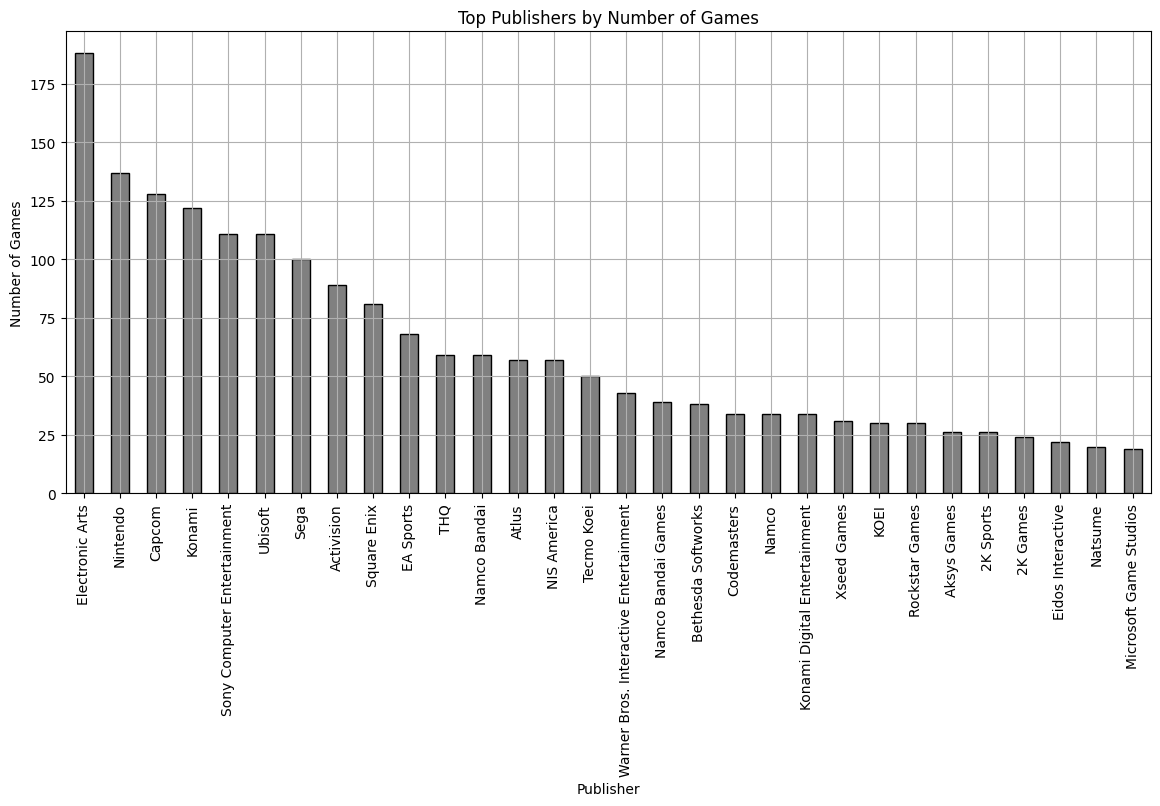

In [103]:
top_publishers.plot(kind='bar', figsize=(14, 6), color='grey', edgecolor='black', grid=True)
plt.title('Top Publishers by Number of Games')
plt.xlabel('Publisher')
plt.ylabel('Number of Games')

Text(0, 0.5, 'Number of Games')

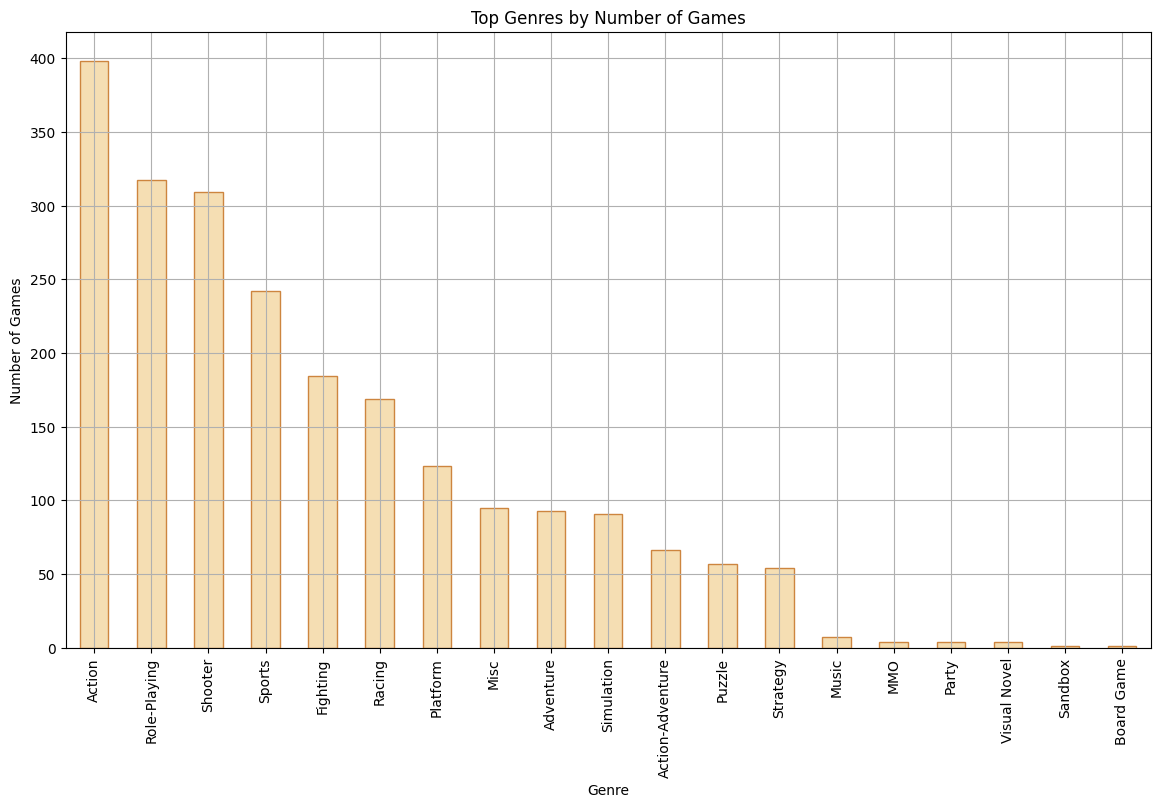

In [96]:
top_genres = df['genre'].value_counts()
top_genres.plot(kind='bar', figsize=(14, 8), color='wheat', edgecolor='peru', grid=True)
plt.title('Top Genres by Number of Games')       
plt.xlabel('Genre')
plt.ylabel('Number of Games')

Text(0, 0.5, 'Number of Games')

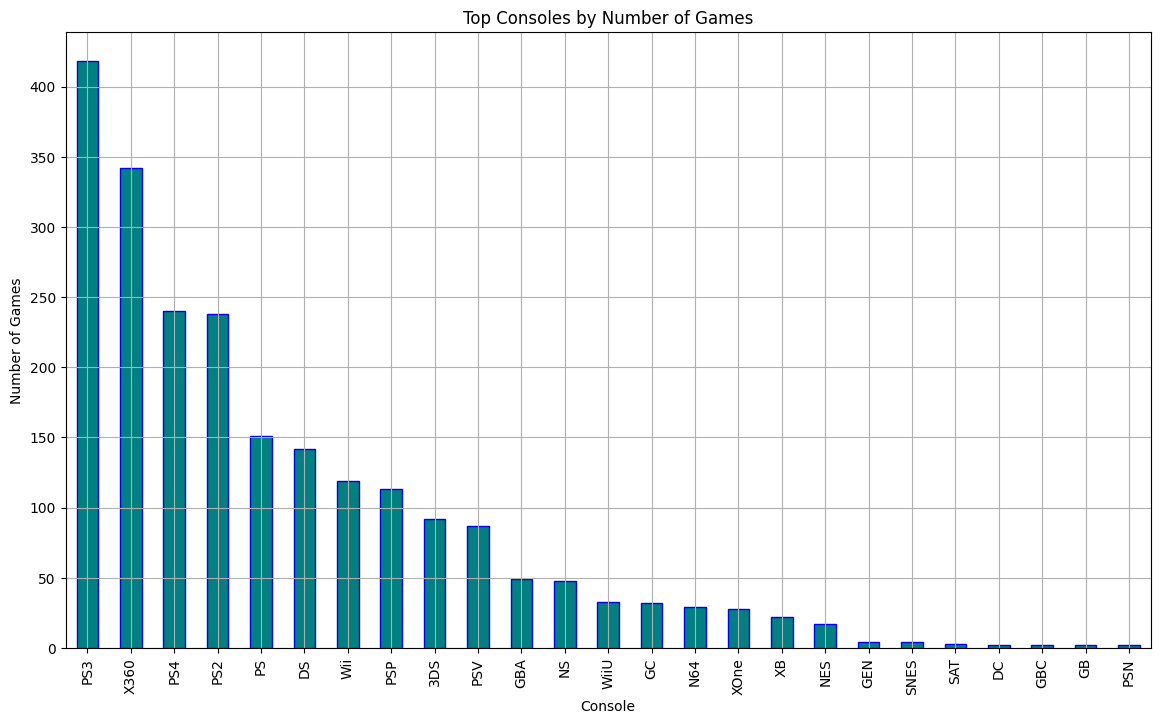

In [95]:
top_consoles = df['console'].value_counts()
top_consoles.plot(kind='bar', figsize=(14, 8), color='teal', edgecolor='blue', grid=True)
plt.title('Top Consoles by Number of Games')
plt.xlabel('Console')   
plt.ylabel('Number of Games')


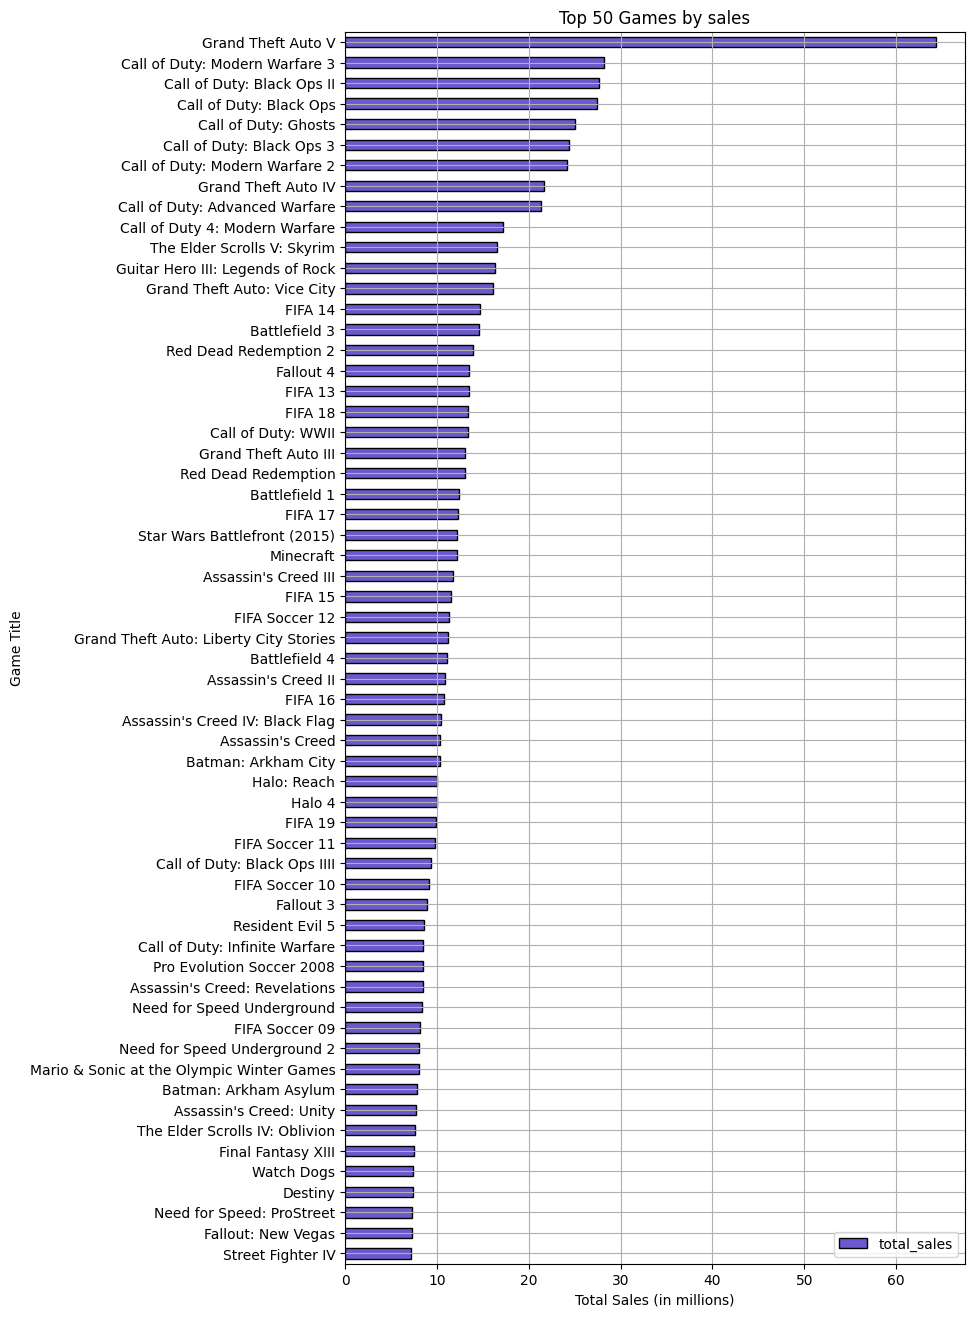

In [ ]:
game_sales = df.groupby('title')['total_sales'].sum().sort_values(ascending=False).round(2).reset_index()
game_sales_df = game_sales.head(60)
game_sales_df.plot(x='title', y='total_sales', kind='barh', figsize=(8, 16), color='slateblue', edgecolor='black', grid=True)
plt.title('Top 50 Games by sales')
plt.ylabel('Game Title')        
plt.xlabel('Total Sales (in millions)')
plt.gca().invert_yaxis()

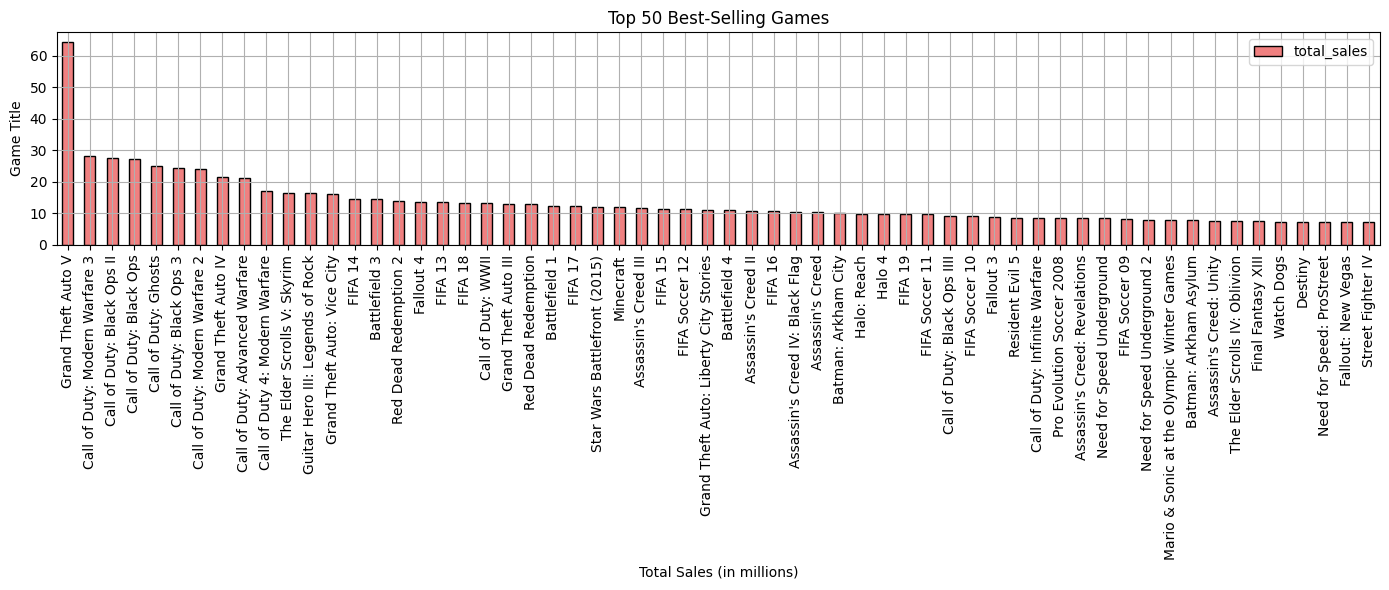

In [154]:
top_50 = game_sales_df.head(60)
top_50.plot(x='title', y='total_sales', kind='bar',figsize=(14, 6), color='lightcoral', edgecolor='black', grid=True)
plt.title("Top 50 Best-Selling Games")
plt.xlabel("Total Sales (in millions)")
plt.ylabel("Game Title")
plt.tight_layout()
plt.show()

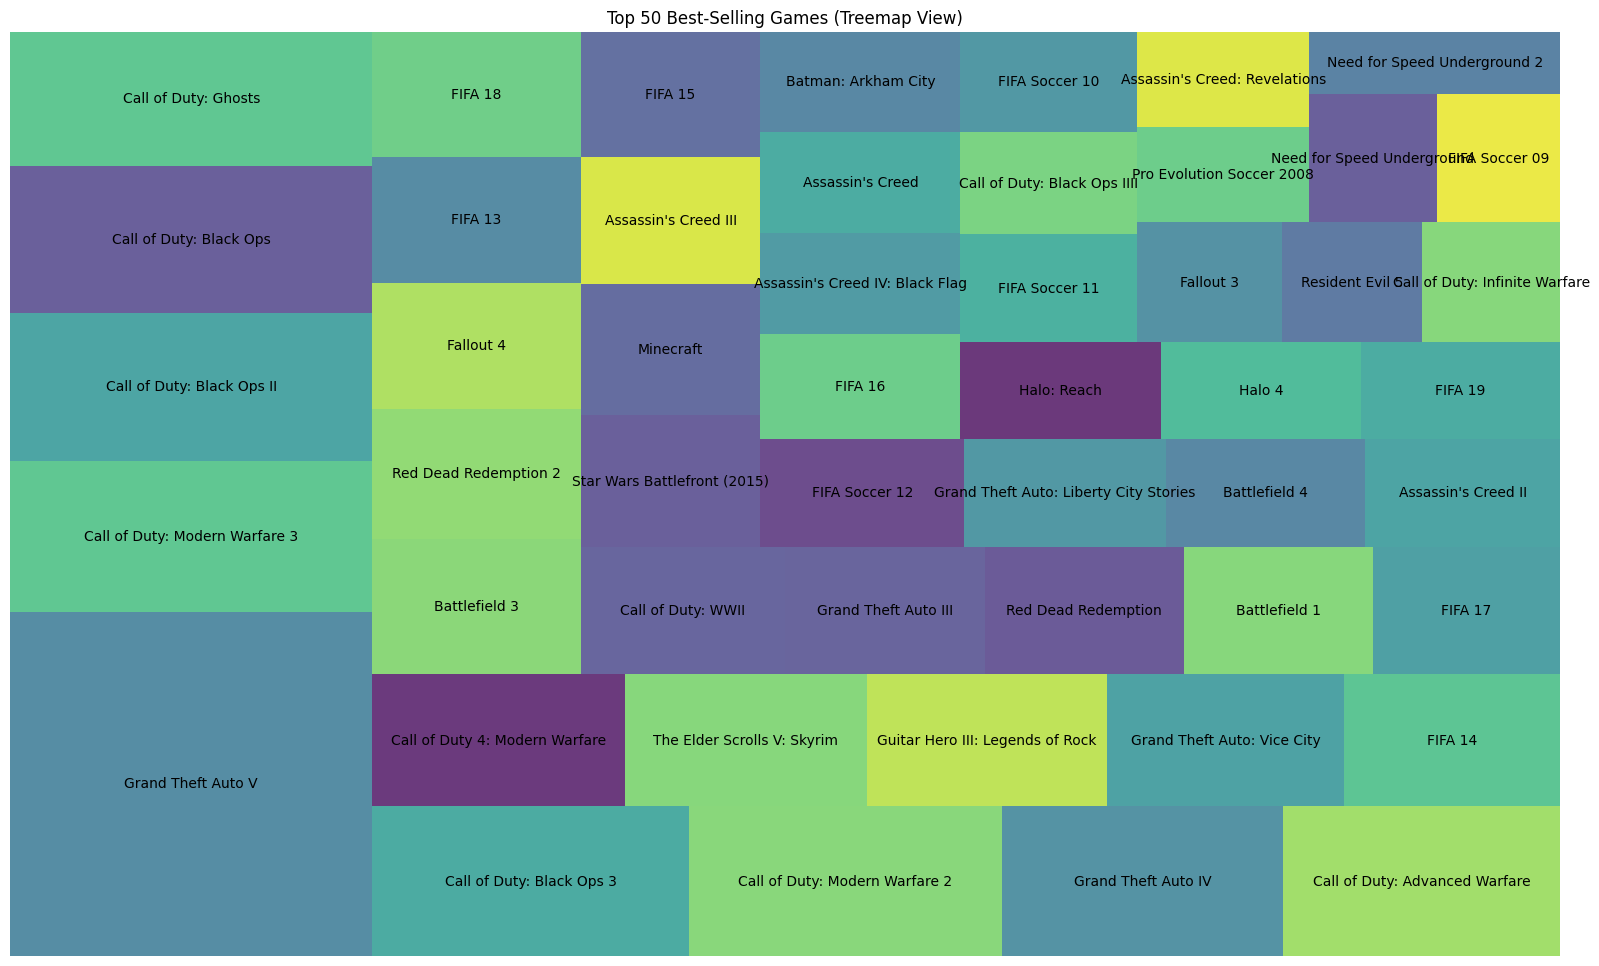

In [136]:
# Prepare data
top_games = game_sales_df.head(50)

# Plot treemap
plt.figure(figsize=(20, 12))
squarify.plot(sizes=top_50['total_sales'], label=top_50['title'], alpha=.8)
plt.axis('off')
plt.title("Top 50 Best-Selling Games (Treemap View)")
plt.show()
